# Experimental Tree Counter Evaluation

## tl;dr
This notebook evaluates the selected YOLO11n checkpoint on the untouched test split. It reports object-detection quality and the image-level count errors that matter to the application.

## Context & Methods

The model was trained for 30 epochs on 64 images and selected using 18 validation images. The confidence threshold is chosen on validation count MAE only, then frozen before evaluating the 9 test images.

### Key Assumptions
Each labelled box is one tree crown. MAE and RMSE are measured in trees per image. MAPE is reported because every test image has at least one labelled crown.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'tree-counting-model').exists())
dataset_root = project_root / 'tree-counting-model' / 'dataset1'
model_path = project_root / 'tree-counting-model' / 'best_tree_counter.pt'
model = YOLO(model_path)
print(f'Model: {model_path.name}')
print('Train/validation/test images: 64 / 18 / 9')

Model: best_tree_counter.pt
Train/validation/test images: 64 / 18 / 9


## Results

### 1. Detection metrics
Precision measures how many predicted crowns match annotations; recall measures how many annotated crowns are found. mAP summarizes localization performance across confidence and IoU thresholds.

In [2]:
metrics = model.val(data=str(dataset_root / 'data.yaml'), split='test', imgsz=640, device='mps', plots=False, verbose=False)
detection_metrics = {
    'Precision': float(metrics.box.mp),
    'Recall': float(metrics.box.mr),
    'mAP50': float(metrics.box.map50),
    'mAP50-95': float(metrics.box.map),
}
for name, value in detection_metrics.items():
    print(f'{name:10}: {value:.3f}')

Ultralytics 8.4.131 🚀 Python-3.14.7 torch-2.13.0 MPS (Apple M5)


YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3063.5±823.2 MB/s, size: 90.6 KB)


val: Scanning /Users/joseph/Desktop/DS Proejct/ai-first-nations/tree-counting-model/dataset1/test/labels.cache... 9 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 9/9 2.2Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.0it/s 0.3s

                   all          9        759      0.789      0.739      0.779      0.324


Speed: 4.5ms preprocess, 11.0ms inference, 0.0ms loss, 5.1ms postprocess per image


Precision : 0.789
Recall    : 0.739
mAP50     : 0.779
mAP50-95  : 0.324


### 2. Select a count threshold on validation
Predictions are generated once at a low threshold. Candidate thresholds are compared using validation MAE, without looking at test counts.

In [3]:
def load_predictions(split):
    images = sorted((dataset_root / split / 'images').glob('*'))
    results = model.predict([str(path) for path in images], imgsz=640, conf=0.05, device='mps', verbose=False)
    actual = np.asarray([len((dataset_root / split / 'labels' / f'{path.stem}.txt').read_text().splitlines()) for path in images])
    confidence = [result.boxes.conf.cpu().numpy() for result in results]
    return images, actual, confidence

validation_images, validation_actual, validation_confidence = load_predictions('valid')
threshold_rows = []
for threshold in (0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40):
    predicted = np.asarray([(values >= threshold).sum() for values in validation_confidence])
    errors = predicted - validation_actual
    threshold_rows.append((threshold, np.abs(errors).mean(), np.sqrt(np.mean(errors ** 2))))
selected_threshold = min(threshold_rows, key=lambda row: row[1])[0]
for threshold, mae, rmse in threshold_rows:
    marker = ' <- selected' if threshold == selected_threshold else ''
    print(f'{threshold:.2f}  MAE={mae:5.2f}  RMSE={rmse:5.2f}{marker}')

0.05  MAE=73.50  RMSE=81.93
0.10  MAE=19.72  RMSE=25.04
0.15  MAE= 6.22  RMSE= 7.80 <- selected
0.20  MAE=15.00  RMSE=18.17
0.25  MAE=28.50  RMSE=31.65
0.30  MAE=44.11  RMSE=47.34
0.40  MAE=70.94  RMSE=76.35


### 3. Test count accuracy
The selected threshold is now applied once to the untouched test images. The chart makes systematic undercounting visible rather than hiding it behind one aggregate score.

In [4]:
test_images, test_actual, test_confidence = load_predictions('test')
test_predicted = np.asarray([(values >= selected_threshold).sum() for values in test_confidence])
errors = test_predicted - test_actual
count_metrics = {
    'MAE (trees/image)': np.abs(errors).mean(),
    'RMSE (trees/image)': np.sqrt(np.mean(errors ** 2)),
    'MAPE': np.mean(np.abs(errors) / test_actual) * 100,
    'Mean bias': errors.mean(),
}
for name, value in count_metrics.items():
    suffix = '%' if name == 'MAPE' else ''
    print(f'{name:18}: {value:.2f}{suffix}')
print(f'Total actual/predicted: {test_actual.sum()} / {test_predicted.sum()}')

MAE (trees/image) : 15.56
RMSE (trees/image): 24.25
MAPE              : 15.74%
Mean bias         : -14.89
Total actual/predicted: 759 / 625


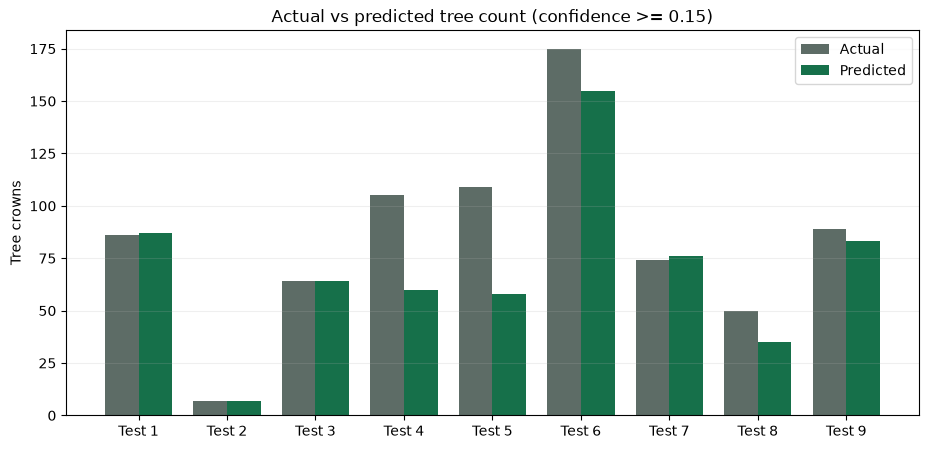

In [5]:
positions = np.arange(len(test_images))
width = 0.38
plt.figure(figsize=(11, 5))
plt.bar(positions - width / 2, test_actual, width, label='Actual', color='#5d6c66')
plt.bar(positions + width / 2, test_predicted, width, label='Predicted', color='#16704a')
plt.xticks(positions, [f'Test {index + 1}' for index in positions])
plt.ylabel('Tree crowns')
plt.title(f'Actual vs predicted tree count (confidence >= {selected_threshold:.2f})')
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

## Takeaways

In [6]:
print('Status: EXPERIMENTAL')
print('The baseline detects many crowns but undercounts the densest test images.')
print('Use it for integration and further evaluation, not as a validated exact tree inventory.')
print('Next improvement: expand diverse labelled imagery and inspect missed crowns in dense scenes.')

Status: EXPERIMENTAL
The baseline detects many crowns but undercounts the densest test images.
Use it for integration and further evaluation, not as a validated exact tree inventory.
Next improvement: expand diverse labelled imagery and inspect missed crowns in dense scenes.
